<a href="https://colab.research.google.com/github/MCarvajalR/BootcampTalentoTech/blob/main/experiencia/Red_neuronal_para_regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

X_train:  (11610, 8)
X_test:  (5160, 8)
X_valid:  (3870, 8)
y_train:  (11610,)
y_test:  (5160,)
y_valid:  (3870,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.8285 - mean_absolute_percentage_error: 38.1443 - root_mean_squared_error: 0.9102 - val_loss: 0.5652 - val_mean_absolute_percentage_error: 32.2499 - val_root_mean_squared_error: 0.7518
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.8049 - mean_absolute_percentage_error: 31.6633 - root_mean_squared_error: 0.8971 - val_loss: 0.4891 - val_mean_absolute_percentage_error: 26.6128 - val_root_mean_squared_error: 0.6994
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4545 - mean_absolute_percentage_error: 27.3298 - root_mean_squared_error: 0.6742 - val_loss: 0.4546 - val_mean_absolute_percentage_error: 26.6558 - val_root_mean_squared_error: 0.6743
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4297 - mean_absolute_percentage_error: 26.3492 - root_mean_squared_error: 0.6555 - val_loss: 0.5908 - val_mean_absolute_percentage_error: 27.7688 - val_root_mean_squared_error: 0.7687
Epoch 5/10
363/3

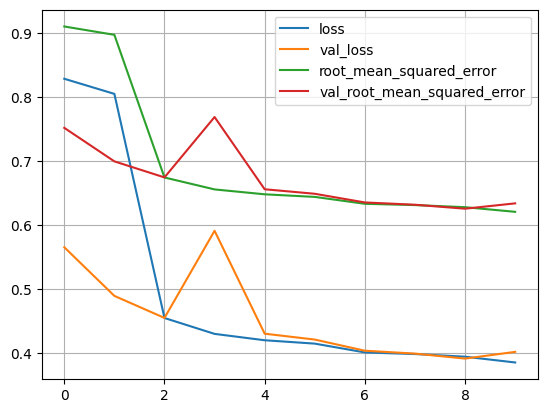

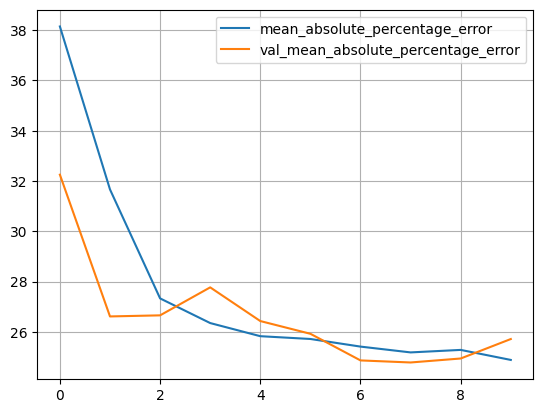

In [ ]:
import keras
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import pandas as pd
import matplotlib as plt

#cargar el conjunto de datos
housing = fetch_california_housing()

#crear conjunto de datos de entrenamiento, validacion y prueba
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full)

print("X_train: ", X_train.shape)
print("X_test: ", X_test.shape)
print("X_valid: ", X_valid.shape)
print("y_train: ", y_train.shape)
print("y_test: ", y_test.shape)
print("y_valid: ", y_valid.shape)


#escalar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_valid = scaler.transform(X_valid)

#crear el modelo de red neuronal
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]), keras.layers.Dense(1)
])

#compilar el modelo
model.compile(loss='mean_squared_error', optimizer='sgd',metrics=[keras.metrics.RootMeanSquaredError(), 'mean_absolute_percentage_error'])

#entrenar el modelo
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

#graficar el historial de entrenamiento
dfHistory=pd.DataFrame(history.history)
dfHistory[['loss', 'val_loss', 'root_mean_squared_error', 'val_root_mean_squared_error']].plot(grid=True)
dfHistory[['mean_absolute_percentage_error', 'val_mean_absolute_percentage_error']].plot(grid=True)

#evalluar el modelo
loss, RMSE, MAPE = model.evaluate(X_train, y_train)
print("Evaluar el modelo en el conjuntode  entrenamiento")
print("loss_train: ", loss)
print("Root_mean_squared_error_train: ", RMSE)
print("Mean_absolute_percentage_error train: ", MAPE)

#Evaluar el modelo en el conjunto de validacion
loss, RMSE, MAPE = model.evaluate(X_valid, y_valid)
print("Evaluar el modelo en el conjunto de validacion")
print("loss_valid: ", loss)
print("loss valid", loss)
print("Root_mean_squared_error_valid: ", RMSE)
print("Mean_absolute_percentage_error valid: ", MAPE)

#Evaluar el modelo en el conjunto de prueba
loss, RMSE, MAPE = model.evaluate(X_test, y_test)
print("Evaluar el modelo en el conjunto de prueba")
print("loss_test: ", loss)
print("Root_mean_squared_error_test: ", RMSE)
print("Mean_absolute_percentage_error test: ", MAPE)